# House Prices - Advanced Regression

Kaggle competition: predict residential sale prices in Ames, Iowa.  
Dataset: 79 features (structural, neighbourhood, quality) across 1,460 training observations.

**Approach:** compare nine regression models with light hyperparameter tuning, then train the winner on the full dataset for submission.

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np

test_data  = pd.read_csv('data/test.csv')
train_data = pd.read_csv('data/train.csv')

# drop rows with no sale price, then split target from features
train_data.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = train_data.SalePrice
X = train_data.drop(['SalePrice'], axis=1)

print(f'Train : {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Test  : {test_data.shape[0]:,} rows')


Train : 1,460 rows, 80 features
Test  : 1,459 rows


## 2. Exploratory Data Analysis

Before modelling, three questions matter most:
- How is `SalePrice` distributed?
- Which features have the most missing values?
- Which numeric features correlate most strongly with price?


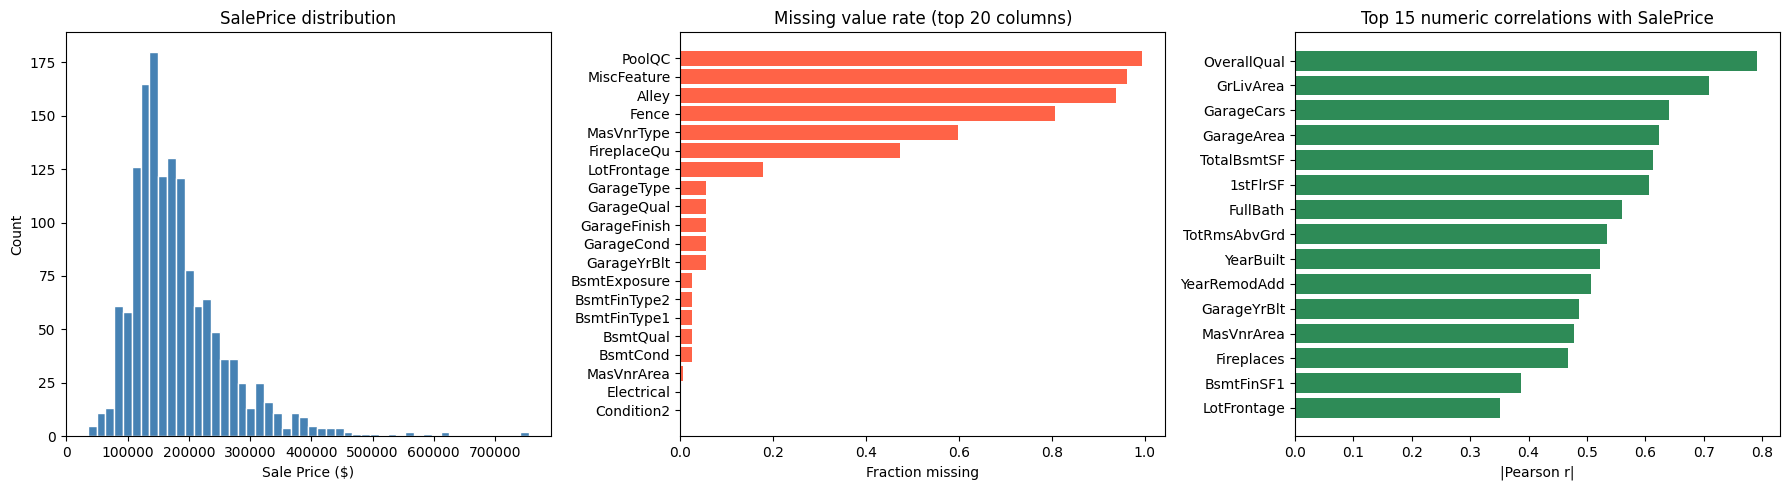


SalePrice skewness : 1.88
Columns with >40% missing: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a. SalePrice distribution
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

# 2b. Missing values — top 20 columns
missing = X.isnull().mean().sort_values(ascending=False).head(20)
axes[1].barh(missing.index[::-1], missing.values[::-1], color='tomato')
axes[1].set_title('Missing value rate (top 20 columns)')
axes[1].set_xlabel('Fraction missing')

# 2c. Top numeric correlations with SalePrice
num_cols = X.select_dtypes(exclude=['object']).columns
corr = train_data[num_cols.tolist() + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(15)
axes[2].barh(corr.index[::-1], corr.values[::-1], color='seagreen')
axes[2].set_title('Top 15 numeric correlations with SalePrice')
axes[2].set_xlabel('|Pearson r|')

plt.tight_layout()
plt.show()

print(f'\nSalePrice skewness : {y.skew():.2f}')
print(f'Columns with >40% missing: {list(missing[missing > 0.4].index)}')


**Observations:**
- `SalePrice` is right-skewed (skewness ~1.9). Models that minimise squared error are sensitive to large outliers, so this is worth noting.
- `PoolQC`, `MiscFeature`, `Alley`, and `Fence` are missing in over 80% of rows - effectively absent features.
- `OverallQual`, `GrLivArea`, and `GarageCars` have the strongest linear relationships with price, which aligns with intuition.


## 3. Preprocessing

Two decisions here:
- **Numeric columns:** impute with the column median (robust to outliers), then standard-scale so regularised models and KNN aren't distorted by feature magnitude.
- **Categorical columns:** impute with the mode, then one-hot encode. `handle_unknown='ignore'` ensures any category in the test set that wasn't in training doesn't break prediction.

Everything is wrapped in a `ColumnTransformer` so the same pipeline applies cleanly to both validation and test data, no leakage from fitting on the full dataset.


In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

num_cols = X.select_dtypes(exclude=['object']).columns
cat_cols = X.select_dtypes(include=['str']).columns

# numeric: impute median → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical: impute mode → one-hot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# fit on train, apply to valid
X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc  = preprocessor.transform(X_valid)

print(f'Processed shape: {X_train_proc.shape}')


Processed shape: (1168, 283)


## 4. Model Comparison

Nine models spanning different complexity levels: linear baselines, tree ensembles, and gradient boosters.  
Each is tuned with a small grid search (3-fold CV) to avoid comparing default configs unfairly.  
Metric: **RMSE on the held-out validation set** (20% of training data).

> Lasso may show a convergence warning at default `max_iter`. This is expected,its RMSE is still recorded correctly.


In [6]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

def rmse(true, predicted):
    return np.sqrt(mean_squared_error(true, predicted))

models = {
    'Linear Regression'      : LinearRegression(),
    'Ridge Regression'       : Ridge(),
    'Lasso Regression'       : Lasso(),
    'KNN Regressor'          : KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'AdaBoost Regressor'     : AdaBoostRegressor(),
    'XGBRegressor'           : XGBRegressor(),
    'CatBoostRegressor'      : CatBoostRegressor(verbose=False)
}

params = {
    'Decision Tree Regressor': {'criterion': ['squared_error', 'friedman_mse', 'absolute_error']},
    'Random Forest Regressor': {'n_estimators': [16, 32, 64, 128]},
    'AdaBoost Regressor'     : {'learning_rate': [0.1, 0.05, 0.01], 'n_estimators': [32, 64, 128]},
    'XGBRegressor'           : {'learning_rate': [0.1, 0.05, 0.01], 'n_estimators': [32, 64, 128]},
    'CatBoostRegressor'      : {'depth': [6, 8], 'learning_rate': [0.05, 0.1], 'iterations': [50, 100]},
    'KNN Regressor'          : {'n_neighbors': [5, 7, 9]},
    'Linear Regression'      : {},
    'Ridge Regression'       : {},
    'Lasso Regression'       : {}
}

model_list, rmse_list = [], []

for name, model in models.items():
    print(f'Tuning {name}...')
    gs = GridSearchCV(model, params.get(name, {}), cv=3,
                      scoring='neg_mean_squared_error', n_jobs=1)
    gs.fit(X_train_proc, y_train)
    score = rmse(y_valid, gs.best_estimator_.predict(X_valid_proc))
    model_list.append(name)
    rmse_list.append(score)
    print(f'  params : {gs.best_params_}')
    print(f'  RMSE   : ${score:,.2f}\n')

leaderboard = (
    pd.DataFrame({'Model': model_list, 'RMSE': rmse_list})
    .sort_values('RMSE')
    .reset_index(drop=True)
)
leaderboard


Tuning Linear Regression...
  params : {}
  RMSE   : $59,394.58

Tuning Ridge Regression...
  params : {}
  RMSE   : $49,883.00

Tuning Lasso Regression...


e:\Repositories\house-prices-ml\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.724e+09, tolerance: 4.885e+08
  model = cd_fast.enet_coordinate_descent(
e:\Repositories\house-prices-ml\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.726e+09, tolerance: 4.243e+08
  model = cd_fast.enet_coordinate_descent(


  params : {}
  RMSE   : $57,398.02

Tuning KNN Regressor...
  params : {'n_neighbors': 9}
  RMSE   : $45,583.18

Tuning Decision Tree Regressor...
  params : {'criterion': 'absolute_error'}
  RMSE   : $37,474.80

Tuning Random Forest Regressor...
  params : {'n_estimators': 64}
  RMSE   : $34,852.45

Tuning AdaBoost Regressor...
  params : {'learning_rate': 0.1, 'n_estimators': 128}
  RMSE   : $40,254.38

Tuning XGBRegressor...
  params : {'learning_rate': 0.1, 'n_estimators': 128}
  RMSE   : $32,637.49

Tuning CatBoostRegressor...
  params : {'depth': 6, 'iterations': 100, 'learning_rate': 0.1}
  RMSE   : $32,801.37



,Model,RMSE
0,XGBRegressor,32637.485197
1,CatBoostRegressor,32801.365556
2,Random Forest Regressor,34852.446375
3,Decision Tree Regressor,37474.801232
4,AdaBoost Regressor,40254.377214
5,KNN Regressor,45583.179228
6,Ridge Regression,49883.004973
7,Lasso Regression,57398.016779
8,Linear Regression,59394.580869


**Result:** XGBoost and CatBoost are nearly tied at ~\$32.6k RMSE. Both are gradient boosting methods, they win here for the same reason: they handle the mix of numeric and categorical signal well, and their sequential tree structure captures nonlinear interactions (e.g. quality × size) that linear models miss.  

XGBoost is selected as the final model by a small margin.


## 5. Final Model Evaluation

Two additional checks on the winning XGBoost model:
- **R²** — proportion of variance in sale price explained by the model
- **Predicted vs. actual plot** — visual check for systematic bias (a well-calibrated model scatters evenly around the diagonal)


R²       : 84.58%
Accuracy : 90.63%


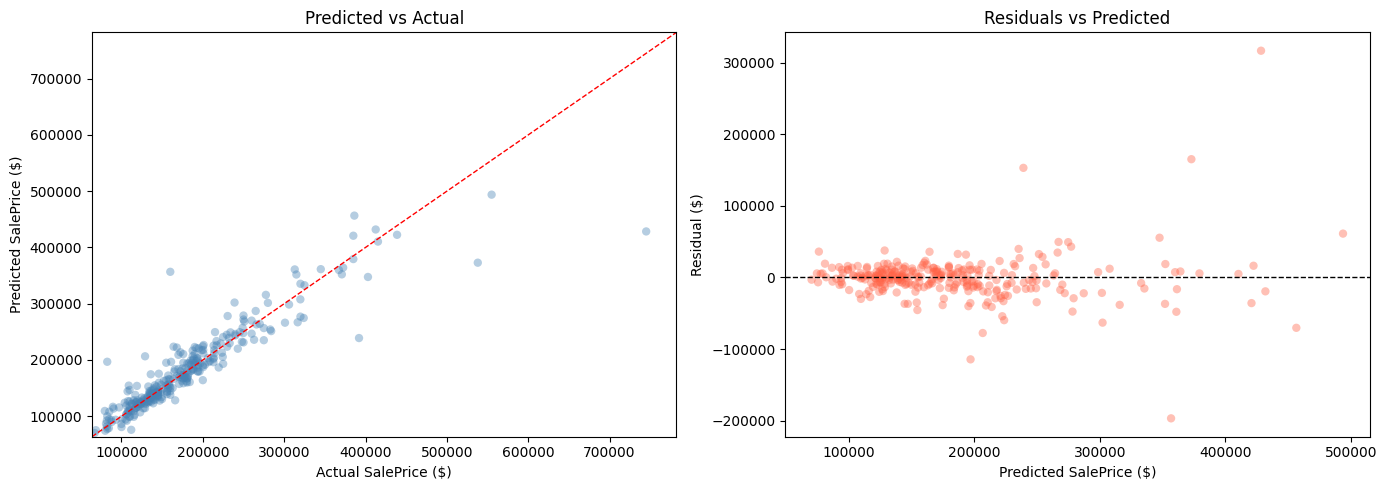

In [7]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

final_val_model = XGBRegressor(learning_rate=0.1, n_estimators=128)
final_val_model.fit(X_train_proc, y_train)
preds = final_val_model.predict(X_valid_proc)

r2       = r2_score(y_valid, preds)
accuracy = 1 - mean_absolute_percentage_error(y_valid, preds)
print(f'R²       : {r2:.2%}')
print(f'Accuracy : {accuracy:.2%}')

# Predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_valid, preds, alpha=0.4, color='steelblue', edgecolors='none')
lim = (min(y_valid.min(), preds.min()) * 0.95, max(y_valid.max(), preds.max()) * 1.05)
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].set_title('Predicted vs Actual')

# Residuals
residuals = y_valid - preds
axes[1].scatter(preds, residuals, alpha=0.4, color='tomato', edgecolors='none')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted SalePrice ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


Predictions track actual prices closely across most of the range. The residual plot is mostly random around zero, with some underprediction on the highest-value homes - a common pattern when expensive outliers are sparse in training data.


## 6. Feature Importance

XGBoost assigns importance scores based on how often each feature is used in a split and how much it reduces error. The top features here align with domain knowledge: overall quality, living area, and garage capacity are the strongest drivers of price.

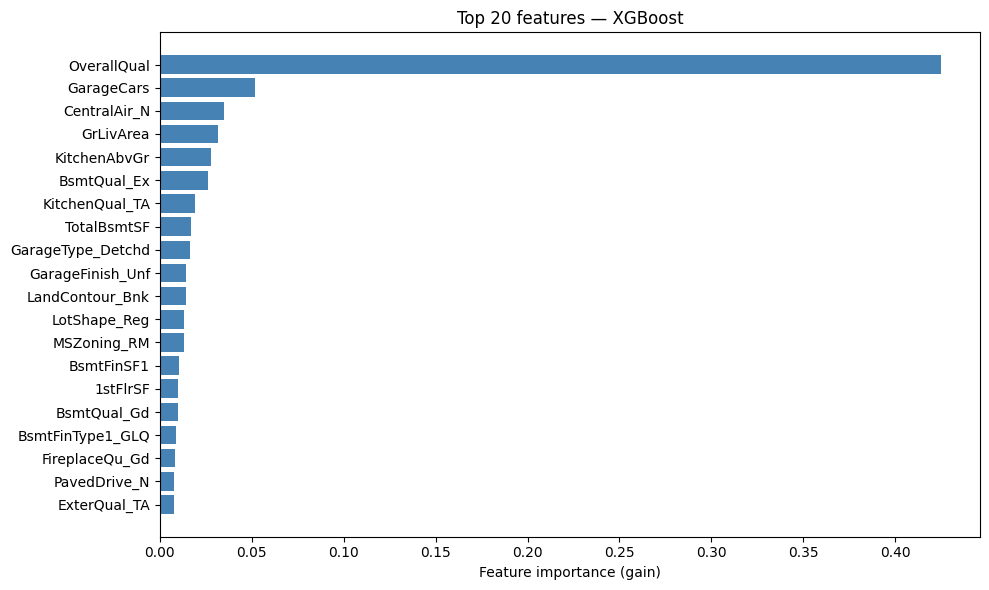

In [9]:
# Reconstruct feature names after ColumnTransformer
ohe_features = (
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
)
feature_names = list(num_cols) + list(ohe_features)

importances = pd.Series(final_val_model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 features — XGBoost')
plt.tight_layout()
plt.show()


## 7. Submission

The final model is retrained on the **full training dataset** (not just the 80% split) before predicting on the test set. This gives the model the most signal possible - the validation split was only needed to compare models.


In [10]:
import xgboost as xgb

# fit preprocessor and model on ALL training data
X_full_proc  = preprocessor.fit_transform(X)
X_test_proc  = preprocessor.transform(test_data)

final_model = xgb.XGBRegressor(learning_rate=0.1, n_estimators=128)
final_model.fit(X_full_proc, y)

final_preds = final_model.predict(X_test_proc)

submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head()


Saved submission.csv


,Id,SalePrice
0,1461,125536.335938
1,1462,151252.984375
2,1463,184190.968750
3,1464,188217.578125
4,1465,200537.890625
